In [15]:
# Assignment 6
import pandas as pd

# Load dataset
data = pd.read_csv("sales_data_sample.csv", encoding='latin1')

# Inspect first few rows
data.head()


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [16]:
from sklearn.preprocessing import StandardScaler

# Select numeric columns for clustering
numeric_cols = ['QUANTITYORDERED', 'PRICEEACH', 'SALES']
numeric_data = data[numeric_cols]

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_data)

scaled_data[:5]  # Show first 5 rows after scaling


array([[-0.52289086,  0.5969775 , -0.37082523],
       [-0.11220131, -0.11445035, -0.42789707],
       [ 0.60650538,  0.54938372,  0.17944282],
       [ 1.01719493, -0.01975856,  0.10470098],
       [ 1.42788447,  0.81015797,  0.89673966]])

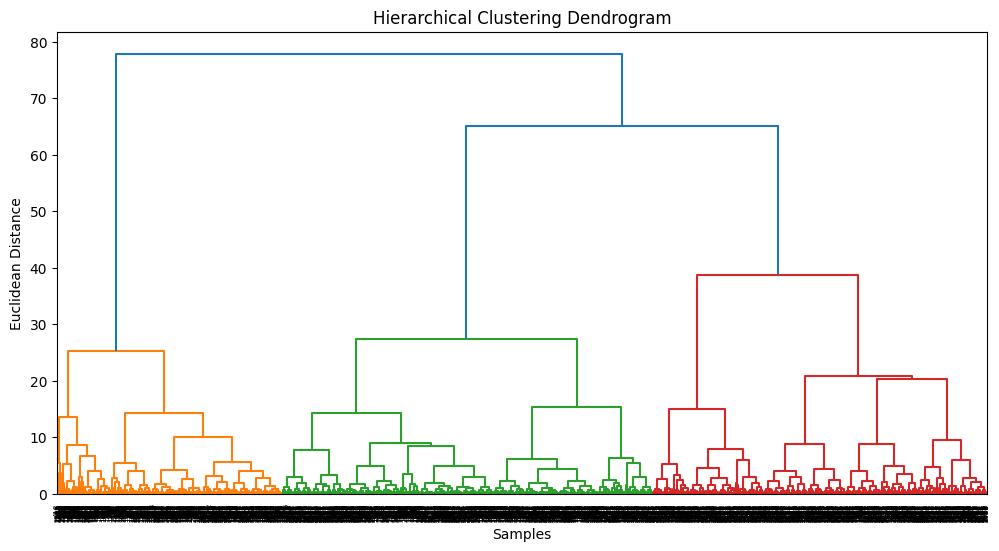

In [17]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# Hierarchical clustering using Ward's method
linked = linkage(scaled_data, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='level', p=20)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Euclidean Distance')
plt.show()


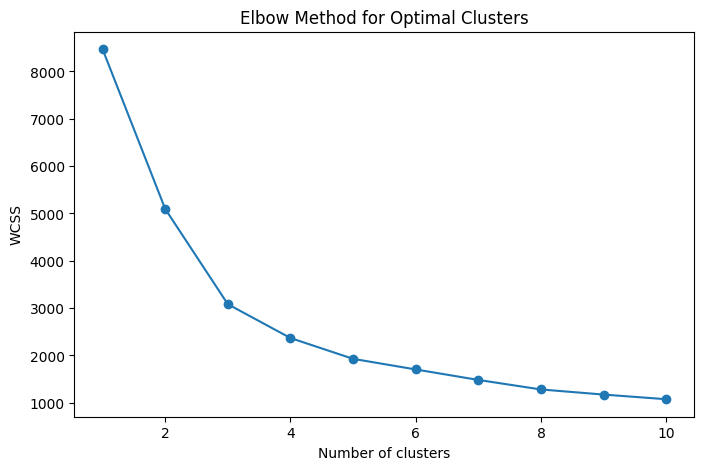

In [18]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Plot the elbow
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()


In [19]:
from scipy.cluster.hierarchy import fcluster

# Choose number of clusters based on dendrogram/elbow
optimal_clusters = 3

# Assign clusters
data['Cluster'] = fcluster(linked, optimal_clusters, criterion='maxclust')

# Inspect result
data[['QUANTITYORDERED', 'PRICEEACH', 'SALES', 'Cluster']].head()


,QUANTITYORDERED,PRICEEACH,SALES,Cluster
0,30,95.70,2871.00,2
1,34,81.35,2765.90,2
2,41,94.74,3884.34,1
3,45,83.26,3746.70,3
4,49,100.00,5205.27,1
